<a href="https://colab.research.google.com/github/tata-lakshman/Random_forest/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

#Load the DataSet

In [3]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn (3).csv to customer_churn (3).csv


In [4]:
churn_data=pd.read_csv('customer_churn (3).csv')

#Accessing the top 5 rows

In [5]:
churn_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


customerID
Unique ID for each customer.

gender
Customer’s gender

Male / Female

SeniorCitizen
Whether the customer is a senior citizen

1 = Yes, 0 = No

Partner
Whether the customer has a partner

Yes / No

Dependents
Whether the customer has dependents

Yes / No

tenure
Number of months the customer has stayed with the company.

PhoneService
Whether the customer has phone service

Yes / No

MultipleLines
Whether the customer has multiple phone lines

Yes / No / No phone service

InternetService
Type of internet service

DSL / Fiber optic / No

OnlineSecurity
Whether the customer has online security add-on

Yes / No / No internet service

OnlineBackup
Whether the customer has online backup service

Yes / No / No internet service

DeviceProtection
Whether the customer has device protection

Yes / No / No internet service

TechSupport
Whether the customer has technical support

Yes / No / No internet service

StreamingTV
Whether the customer has streaming TV service

Yes / No / No internet service

StreamingMovies
Whether the customer has streaming movies service

Yes / No / No internet service

Contract
Contract type

Month-to-month / One year / Two year

MonthlyCharges
Amount charged per month.

Churn
Target column

Yes = Customer left

No = Customer stayed

#Columns Names

In [6]:
churn_data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
len(list(churn_data.columns))

21

In [8]:
churn_data.shape

(7043, 21)

#Datatypes of the columns

In [9]:
churn_data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


#Info() it will give datatype as well as missing values

In [10]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#There is so miss match in datatype for TotalCharges it shows object but it is of integer

In [11]:
churn_data['TotalCharges']=pd.to_numeric(churn_data['TotalCharges'],errors='coerce')

#This code converts the 'TotalCharges' column in your churn_data DataFrame to a numeric data type. The pd.to_numeric() function is used for this purpose. The errors='coerce' argument is important here, as it tells pandas to replace any values that cannot be converted to a number (like empty strings or non-numeric text) with NaN (Not a Number), instead of raising an error. This is a common step when cleaning data that was incorrectly read as a string but should be a number.

In [12]:
churn_data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [13]:
churn_data.shape

(7043, 21)

#Missing value Analysis

In [14]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [15]:
churn_data.shape

(7043, 21)

In [16]:
churn_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


#As we can see from above output TotalCharges is having 11 null values,as we don't have an appropriate TotalCharges we will be dropping the 11 null value rows in the same datatable

In [17]:
churn_data.dropna(inplace=True)

In [19]:
churn_data.shape

(7032, 21)

#Customerid is nowhere helping in the predection and also its values are appropriate to fit in the model,We will drop the Customerid column

In [20]:
churn_data.drop(columns=['customerID'],inplace=True)

#The describe by defaule it will display the numerical data only

In [21]:
churn_data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


In [22]:
churn_data.describe(include='object').T

,count,unique,top,freq
gender,7032,2,Male,3549
Partner,7032,2,No,3639
Dependents,7032,2,No,4933
PhoneService,7032,2,Yes,6352
MultipleLines,7032,3,No,3385
InternetService,7032,3,Fiber optic,3096
OnlineSecurity,7032,3,No,3497
OnlineBackup,7032,3,No,3087
DeviceProtection,7032,3,No,3094
TechSupport,7032,3,No,3472


In [23]:
churn_data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

#There are so many categorical colums so we need to Label Encoding

#Label Encoding
Encoding all the labels as numerical categories as because these kind of string data can't be used to as these are incompatible type to fit the classification model
This can be performad through label_encoder() or using the map()function

In [24]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
churn_data['gender'] = encoder.fit_transform(churn_data[['gender']])
churn_data['Churn'] = encoder.fit_transform(churn_data[['Churn']])
churn_data['Contract']=encoder.fit_transform(churn_data[['Contract']])
churn_data['Dependents']=encoder.fit_transform(churn_data[['Dependents']])
churn_data['DeviceProtection']=encoder.fit_transform(churn_data[['DeviceProtection']])
churn_data['InternetService']=encoder.fit_transform(churn_data[['InternetService']])
churn_data['MultipleLines']=encoder.fit_transform(churn_data[['MultipleLines']])
churn_data['OnlineBackup']=encoder.fit_transform(churn_data[['OnlineBackup']])
churn_data['MonthlyCharges']=encoder.fit_transform(churn_data[['MonthlyCharges']])
churn_data['OnlineSecurity']=encoder.fit_transform(churn_data[['OnlineSecurity']])
churn_data['Partner']=encoder.fit_transform(churn_data[['Partner']])
churn_data['PhoneService']=encoder.fit_transform(churn_data[['PhoneService']])
churn_data['PaperlessBilling']=encoder.fit_transform(churn_data[['PaperlessBilling']])
churn_data['PaymentMethod']=encoder.fit_transform(churn_data[['PaymentMethod']])
churn_data['StreamingMovies']=encoder.fit_transform(churn_data[['StreamingMovies']])
churn_data['StreamingTV']=encoder.fit_transform(churn_data[['StreamingTV']])
churn_data['TechSupport']=encoder.fit_transform(churn_data[['TechSupport']])
churn_data['tenure']=encoder.fit_transform(churn_data[['tenure']])


In [25]:
churn_data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0.0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,142.0,29.85,0.0
1,1.0,0,0.0,0.0,33.0,1.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,3.0,497.0,1889.50,0.0
2,1.0,0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,435.0,108.15,1.0
3,1.0,0,0.0,0.0,44.0,0.0,1.0,0.0,2.0,0.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,266.0,1840.75,0.0
4,0.0,0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,728.0,151.65,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1.0,0,1.0,1.0,23.0,1.0,2.0,0.0,2.0,0.0,2.0,2.0,2.0,2.0,1.0,1.0,3.0,990.0,1990.50,0.0
7039,0.0,0,1.0,1.0,71.0,1.0,2.0,1.0,0.0,2.0,2.0,0.0,2.0,2.0,1.0,1.0,1.0,1339.0,7362.90,0.0
7040,0.0,0,1.0,1.0,10.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,137.0,346.45,0.0
7041,1.0,1,1.0,0.0,3.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,794.0,306.60,1.0


#Data Visualization
#Start with visualization that how many customers have churned

In [26]:
churn_data['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
0.0,73.421502
1.0,26.578498


<Axes: xlabel='Churn'>

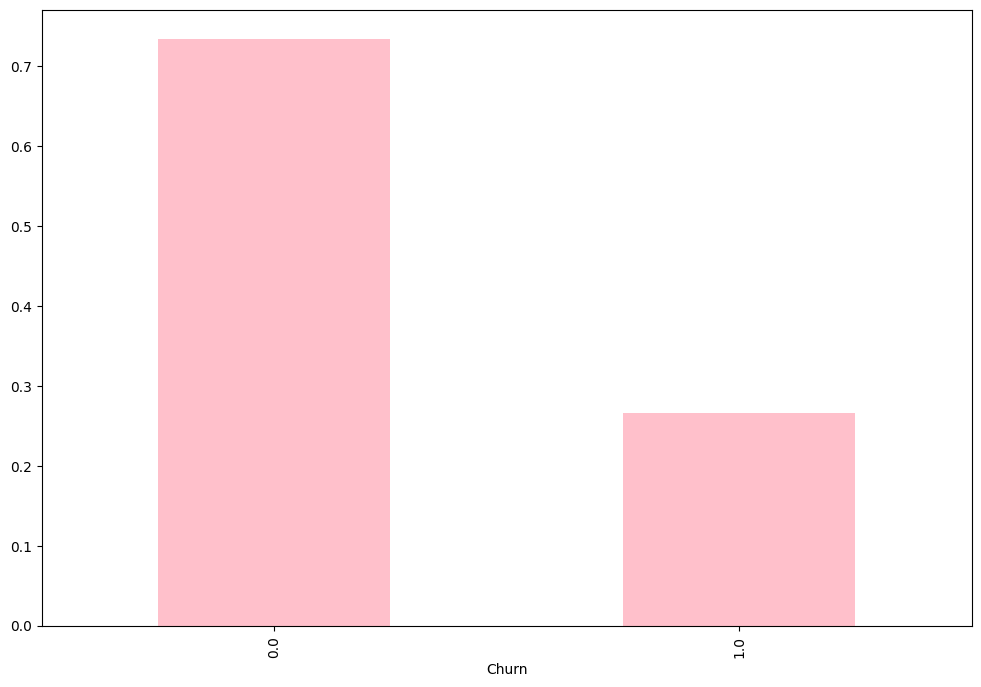

In [27]:
churn_data['Churn'].value_counts(normalize=True).plot(kind='bar',figsize=(12,8),color='pink')

#following shows the 26.5 have churne and 73.4 have not churned

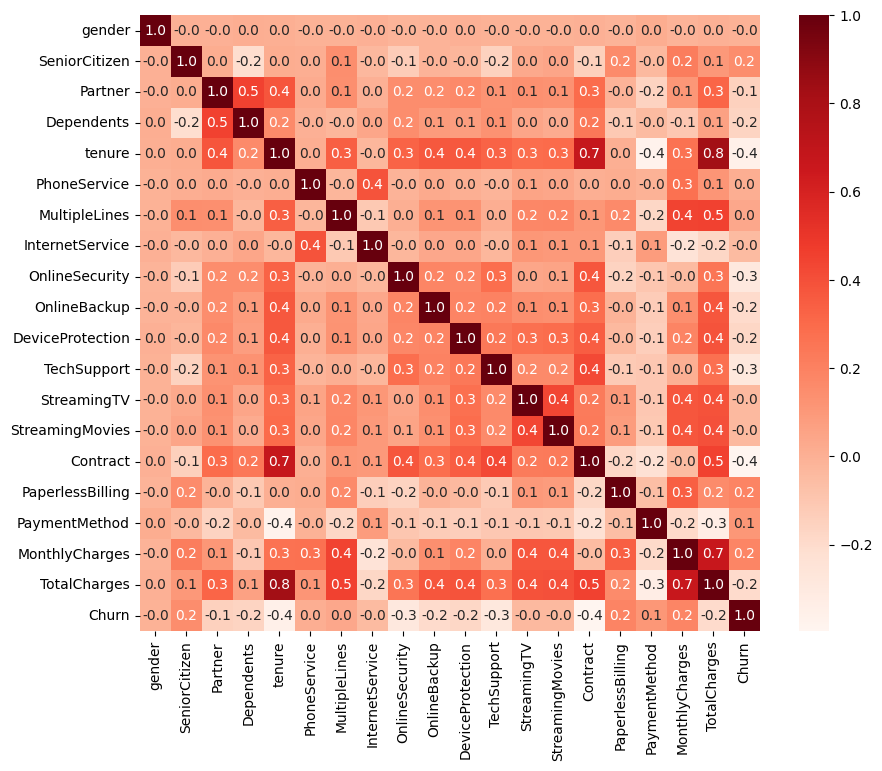

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(churn_data.corr(),cmap='Reds',annot=True,fmt='.1f')
plt.show()

#Model Building
As our main preduction is to check the churning out customers,so we consider churn as dependent data and all other features are considered as independent features after future selection

In [29]:
x=churn_data.iloc[:,:-1]
y=churn_data.iloc[:,-1]

In [30]:
x.shape

(7032, 19)

In [31]:
y

,Churn
0,0.0
1,0.0
2,1.0
3,0.0
4,1.0
...,...
7038,0.0
7039,0.0
7040,0.0
7041,1.0


#Split the data into train and test data,as training data will be used for training the model and test data is for prediction.

In [32]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [33]:
x_test.shape[0]+x_train.shape[0]

7032

#Now we will fit the data into Random Forest classifier,As randomforest is ensemble method.we will be importing randomforest classifier from sklearn's ensemble library

In [34]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(random_state=0)
rf1=rf.fit(x_train,y_train)
y_train_pred=rf1.predict(x_train)
y_test_pred=rf1.predict(x_test)

In [35]:
print(f'Train Accuracy: {accuracy_score(y_train,y_train_pred)*100}')
print(f'Test Accuracy: {accuracy_score(y_test,y_test_pred)*100}')

Train Accuracy: 99.78666666666666
Test Accuracy: 78.96233120113718


#Out of randomforest and the decission tree the random forest is doing the better job still it was overfitting but Testaccuracy is high

#Hyper parameter Tuning


Hyper-parameters are the parameters that defines the model structure,and tuning hyper-parameters is the process of finding the best model structure.So that model structure makes the model more efficient.

There are many parametere while building the randomforest model they are:

#bootstrap/max_sample
The max_sample hyperparameter determines what fraction of the original dataset is given to any individual tree(Whether sampling is with replacement

True → default (good)

False → trees see full data (can overfit))

#n_estimators

Number of trees in the forest

More trees = more stable results

Typical values: 100–500

#max_depth

How deep each tree is allowed to grow

Deeper tree = more learning but more overfitting

Values: None, 10, 20, 30

#min_samples_split

Minimum samples required to split a node

Higher value = less overfitting

Values: 2, 5, 10

#min_samples_leaf

Minimum samples required at a leaf node

Larger value → smoother model

Values: 1, 2, 4

#max_features

Number of features used when splitting a node

auto → use sqrt(number of features)

sqrt → same as auto

log2 → use log2(number of features)

#criterion

How the split quality is measured

For classification:

gini

entropy

For regression:

mse, mae

#class_weight (classification only)

Fixes imbalance

balanced → recommended when dataset has many No’s and few Yes's

#Other optional parameters
#random_state

Makes results reproducible

#max_leaf_nodes

Maximum number of leaf nodes.

#min_weight_fraction_leaf

Minimum weighted fraction of samples at leaf.

There are techniques for hyperparameter tunning(RandomizedSearchCV,GridSearchCV) most used

#Grid Search (GridSearchCV)

Tries every possible combination

Very accurate, but slow for large grids

#Random Search (RandomizedSearchCV)

Tries random combinations

Much faster

Works well for large parameter spaces

#For our model we will be implementing RandomizedSearchCV method and tune our model

#So we'll select the best values for each parameter,below code helps us to extract the best values for each parameter

In [36]:
len(np.linspace(start=200,stop=2000,num=10))*\
len(['auto', 'sqrt'])*\
len([int(x) for x in np.linspace(10,110,11)])*\
len([2,5,10])*\
len([1,2,4])*\
len([True,False])


3960

In [37]:
#If we take 10 min to run for each model then 3960*10=39600
#39600/60
660/24
#It will take 27 days to train the model,so we have RandomizedSearchCV

27.5

In [41]:
max_depth

[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, None]

In [40]:
from sklearn.model_selection import RandomizedSearchCV

#Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
#Number of features to be consider at every split
max_features = ['auto', 'sqrt']
#Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
#Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]
#Minimum number of samples required at each leaf node
min_samples_leaf= [1,2,4]
#Method of selecting samples for training for each tree
bootstrap= [True,False]

#Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap':bootstrap}

print(random_grid)

{'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000], 'max_features': ['auto', 'sqrt'], 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'bootstrap': [True, False]}


#Steps to implement
1.Use the ramdom grid to search for best hyperparameters.

2.First creates the best model to tune

3.Random search of parameters,using 3 fold cross validation.

4.Search across 100 diferent combinations,and use all available cores

5.Fit the random search model

In [42]:
#Use the ramdom grid to search for best hyperparameters.
#First creates the best model to tune
rf=RandomForestClassifier(random_state=0)
#Random search of parameters,using 3 fold cross validation.
#Search across 100 diferent combinations,and use all available cores
rf_random=RandomizedSearchCV(estimator=rf,param_distributions=random_grid,
                             n_iter=100,scoring='neg_mean_absolute_error',
                             cv=3,verbose=2,random_state=0,n_jobs=-1,return_train_score=True)
#Fit the random search model
rf2=rf_random.fit(x_train,y_train);


Fitting 3 folds for each of 100 candidates, totalling 300 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
156 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
96 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils

In [45]:
rf2.best_params_

{'n_estimators': 1200,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 10,
 'bootstrap': True}

In [53]:
rf2=RandomForestClassifier(n_estimators=200,
                           min_samples_split=10,
                           min_samples_leaf=1,
                           max_features='sqrt',
                           max_depth=10,
                           bootstrap=False,random_state=42)
rf2.fit(x_train,y_train)

RandomForestClassifier(bootstrap=False, max_depth=10, min_samples_split=10,
                       n_estimators=200, random_state=42)

From the above fitted model you can check the best values for each paremeter across 10o folds

So after hyperparameter tuning,we have fitted the model with best parameters and the best value

lets check the prediction for the model fitted after tunning

In [54]:
y_train_pred=rf2.predict(x_train)
y_test_pred=rf2.predict(x_test)
print(f'Train Accuracy: {accuracy_score(y_train,y_train_pred)*100}')
print(f'Test Accuracy: {accuracy_score(y_test,y_test_pred)*100}')

Train Accuracy: 88.0
Test Accuracy: 79.74413646055437


#so from the above output we can see there is a 1.2% change in accuracy

overfitting has gone down

#Model Evaluation

we'll check the feature importance of the fitted model.where feature importance helps the contribution of each and every feature for the model

In [55]:
importances=pd.DataFrame(data={
    'Attribute':x_train.columns,
    'Importance':rf2.feature_importances_
})
importances=importances.sort_values(by='Importance',ascending=False)
importances

,Attribute,Importance
4,tenure,0.167216
14,Contract,0.162135
18,TotalCharges,0.148398
17,MonthlyCharges,0.122932
8,OnlineSecurity,0.083183
11,TechSupport,0.067250
7,InternetService,0.053741
16,PaymentMethod,0.039977
9,OnlineBackup,0.028498
15,PaperlessBilling,0.021662


/tmp/ipython-input-838877950.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances['Attribute'],y=importances['Importance'],palette='Set1')


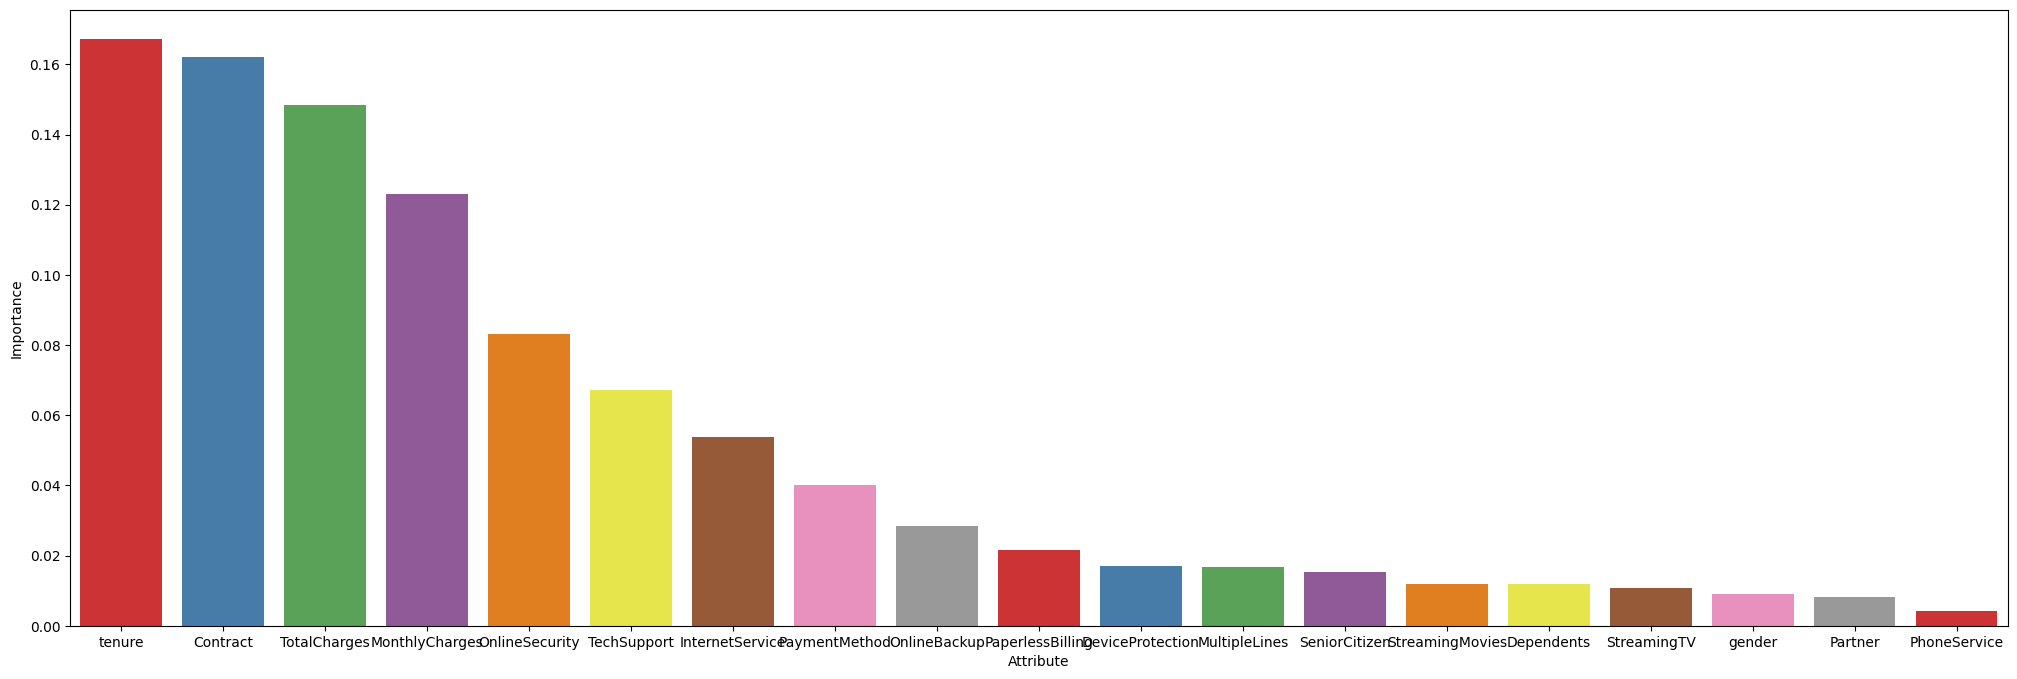

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(25,8))
sns.barplot(x=importances['Attribute'],y=importances['Importance'],palette='Set1')
plt.show()

#Classification_report

classification report helps us to evaluate the model

In [59]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1038
         1.0       0.65      0.50      0.56       369

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [60]:
print(classification_report(y_train,y_train_pred))

              precision    recall  f1-score   support

         0.0       0.89      0.95      0.92      4125
         1.0       0.83      0.69      0.75      1500

    accuracy                           0.88      5625
   macro avg       0.86      0.82      0.84      5625
weighted avg       0.88      0.88      0.88      5625

